In [11]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Add src directory to path
src_path = Path.cwd().parent / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from structure_manager import StructureManager
from poisson_solver import PoissonSolver
from potential_interpolator import PotentialInterpolator
import visualizer as vis

# Import plotly for 3D interactive visualization
try:
    import plotly.graph_objects as go

    plotly_available = True
except ImportError:
    plotly_available = False
    print("Warning: plotly not available. 3D interactive plots will be skipped.")

print("Imports successful!")
if plotly_available:
    print("✓ Plotly available for 3D interactive visualization")

Imports successful!
✓ Plotly available for 3D interactive visualization


In [2]:
# Path to configuration file
config_path = Path.cwd().parent / "configs" / "example.yaml"

# Initialize StructureManager and load configuration
print("Loading structure definition...")
manager = StructureManager(str(config_path))

# Display structure summary
print("\n" + "=" * 60)
print(manager.get_summary())
print("=" * 60)

Loading structure definition...

=== Structure Summary ===
Grid size (nz, nx, ny): (81, 141, 100)
Grid spacing (h): 1.00 nm (isotropic)
Number of layers: 2
Number of electrodes: 4

--- Layers ---
  1. SiO2: z=[0.0, -25.0] nm, εr=3.90
  2. Si: z=[-25.0, -80.0] nm, εr=11.70

--- Electrodes ---
  1. gate_1: V=0.000 V, shape=rectangle
  2. gate_2: V=0.000 V, shape=rectangle
  3. gate_3: V=0.000 V, shape=rectangle
  4. gate_4: V=0.000 V, shape=rectangle


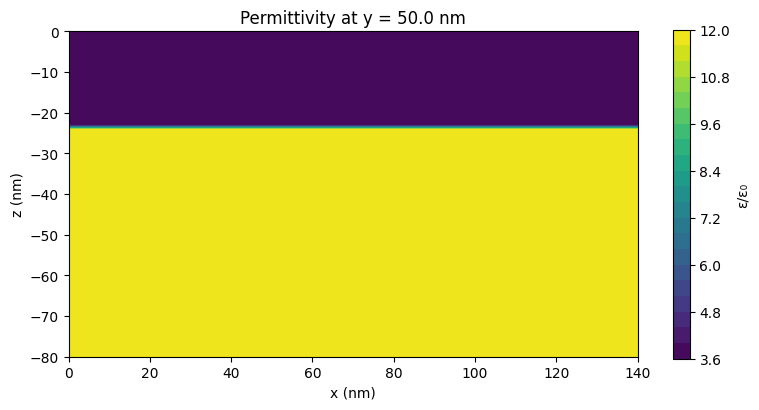

Permittivity range: [3.90, 11.70] ε₀


In [8]:
# Get permittivity distribution (shape: nz, nx, ny)
epsilon = manager.epsilon_array

# Get coordinates
x, y, z = manager.get_grid_coordinates()

# Plot permittivity at different z-positions
fig, ax = plt.subplots(figsize=(8, 4))

y_index = len(y) // 2
title = f"Permittivity at y = {y[y_index]*1e9:.1f} nm"

im = ax.contourf(x * 1e9, z * 1e9, epsilon[:, :, y_index], levels=20, cmap="viridis")
ax.set_xlabel("x (nm)")
ax.set_ylabel("z (nm)")
ax.set_title(title)
ax.set_aspect("equal")
plt.colorbar(im, ax=ax, label="ε/ε₀")

plt.tight_layout()
plt.show()

print(f"Permittivity range: [{epsilon.min():.2f}, {epsilon.max():.2f}] ε₀")

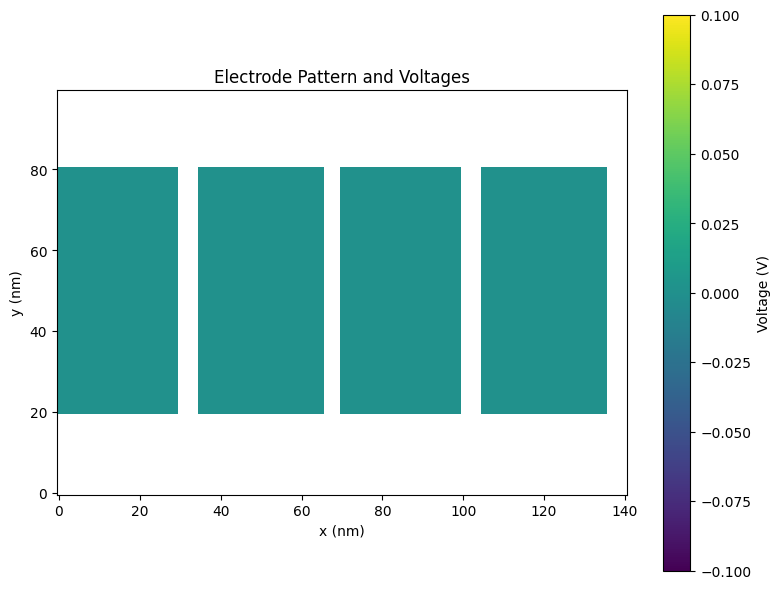

In [9]:
# Plot electrode pattern at surface (z_index=0)
vis.plot_electrode_pattern(
    electrode_mask=manager.electrode_mask,
    electrode_voltages=manager.electrode_voltages,
    x=x,
    y=y,
    z_index=0,
)
plt.show()

In [10]:
import plotly.graph_objects as go

fig = go.Figure()

# Define colors for different materials
material_colors = {"SiO2": "lightblue", "Si": "gray", "electrode": "gold"}


# Function to create a box mesh
def create_box(x_range, y_range, z_range, color, name, opacity=0.5):
    """Create a 3D box using Mesh3d"""
    x_min, x_max = x_range
    y_min, y_max = y_range
    z_min, z_max = z_range

    # 8 vertices of the box
    vertices_x = [x_min, x_max, x_max, x_min, x_min, x_max, x_max, x_min]
    vertices_y = [y_min, y_min, y_max, y_max, y_min, y_min, y_max, y_max]
    vertices_z = [z_min, z_min, z_min, z_min, z_max, z_max, z_max, z_max]

    # 12 triangles (2 per face, 6 faces)
    i = [0, 0, 0, 0, 4, 4, 6, 6, 0, 0, 2, 2]
    j = [1, 2, 3, 4, 5, 6, 7, 2, 5, 1, 6, 3]
    k = [2, 3, 4, 5, 6, 7, 4, 1, 4, 5, 7, 7]

    return go.Mesh3d(
        x=vertices_x,
        y=vertices_y,
        z=vertices_z,
        i=i,
        j=j,
        k=k,
        color=color,
        opacity=opacity,
        name=name,
        showlegend=True,
    )


# Convert to nm for visualization
size_x_nm = manager.size_x * 1e9
size_y_nm = manager.size_y * 1e9

# Add material layers
for layer in manager.layers:
    z_max, z_min = layer["z_range"]
    material = layer["material"]

    box = create_box(
        x_range=[0, size_x_nm],
        y_range=[0, size_y_nm],
        z_range=[z_min * 1e9, z_max * 1e9],
        color=material_colors.get(material, "lightgray"),
        name=f"{material}",
        opacity=0.3,
    )
    fig.add_trace(box)

# Add electrodes
for i, electrode in enumerate(manager.electrodes):
    x_min, x_max = electrode["x_range"]
    y_min, y_max = electrode["y_range"]
    z_position = electrode["z_position"]
    voltage = electrode["voltage"]

    box = create_box(
        x_range=[x_min * 1e9, x_max * 1e9],
        y_range=[y_min * 1e9, y_max * 1e9],
        z_range=[z_position * 1e9, 0],  # From z_position to surface
        color=material_colors["electrode"],
        name=f"{electrode['name']} ({voltage}V)",
        opacity=0.8,
    )
    fig.add_trace(box)

# Add coordinate axes with arrows
axis_length = max(size_x_nm, size_y_nm, abs(manager.size_z * 1e9)) * 0.3

# X-axis (red)
fig.add_trace(
    go.Scatter3d(
        x=[0, axis_length],
        y=[0, 0],
        z=[0, 0],
        mode="lines+text",
        line=dict(color="red", width=4),
        text=["", "x"],
        textposition="top center",
        showlegend=False,
    )
)

# Y-axis (green)
fig.add_trace(
    go.Scatter3d(
        x=[0, 0],
        y=[0, axis_length],
        z=[0, 0],
        mode="lines+text",
        line=dict(color="green", width=4),
        text=["", "y"],
        textposition="top center",
        showlegend=False,
    )
)

# Z-axis (blue)
fig.add_trace(
    go.Scatter3d(
        x=[0, 0],
        y=[0, 0],
        z=[0, -axis_length],
        mode="lines+text",
        line=dict(color="blue", width=4),
        text=["", "z"],
        textposition="middle right",
        showlegend=False,
    )
)

# Add text annotations for key interfaces
annotations = [
    dict(
        x=size_x_nm / 2,
        y=size_y_nm / 2,
        z=0,
        text="Surface (z=0)",
        showarrow=False,
        font=dict(size=10),
    ),
    dict(
        x=size_x_nm / 2,
        y=size_y_nm / 2,
        z=-20,
        text="SiO₂/Si Interface",
        showarrow=False,
        font=dict(size=10, color="red"),
    ),
]

fig.update_layout(
    title="3D Device Structure (Interactive)",
    scene=dict(
        xaxis_title="x (nm)",
        yaxis_title="y (nm)",
        zaxis_title="z (nm)",
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.0)),
        aspectmode="manual",
        aspectratio=dict(x=1, y=1, z=1),
    ),
    width=900,
    height=700,
    showlegend=True,
    legend=dict(x=0.02, y=0.98, bgcolor="rgba(255,255,255,0.8)"),
)

fig.show()

print("✓ 3D structure visualization created")
print(f"  Materials: {', '.join([l['material'] for l in manager.layers])}")
print(f"  Electrodes: {len(manager.electrodes)}")
print("  - Gold: Electrodes")
print("  - Light blue: SiO₂")
print("  - Gray: Si")

✓ 3D structure visualization created
  Materials: SiO2, Si
  Electrodes: 4
  - Gold: Electrodes
  - Light blue: SiO₂
  - Gray: Si


## Initialize the interpolator

In [ ]:
solver_parameters = {
    "tolerance": 1e-5,
    "max_iterations": 10000,
    "omega": 1.8,
}


potinterp = PotentialInterpolator(
    structure_manager=manager,
    z_position=-25e-9,  # 25 nm below surface
    **solver_parameters,
    verbose=2,
)

Target z-position: -25.00 nm
Nearest grid point: z_index=25, z=-25.00 nm
Computing basis functions for 4 electrodes...
  [1/2] Computing particular solution (all V=0, ρ≠0)...
      Converged: True, Iterations: 1
  [2/2] Computing 4 basis functions (ρ=0)...
      [1/4] Electrode: gate_1
      [2/4] Electrode: gate_2
      [3/4] Electrode: gate_3
      [4/4] Electrode: gate_4
Interpolator initialization complete.


Text(0, 0.5, 'Y (nm)')

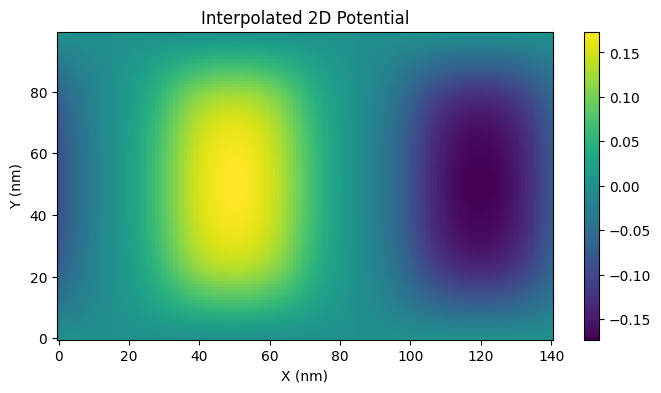

In [25]:
voltages = {
    "gate_1": 0.0,
    "gate_2": 0.5,
    "gate_3": 0.0,
    "gate_4": -0.5,
}


pot2d = potinterp(voltages)

# Plot the interpolated potential
fig, ax = plt.subplots(figsize=(8, 4))
c = ax.pcolormesh(x*1e9, y*1e9, pot2d.T, shading="auto")
fig.colorbar(c, ax=ax)
ax.set_title("Interpolated 2D Potential")
ax.set_xlabel("X (nm)")
ax.set_ylabel("Y (nm)")